**AFOS — Personal Finance Dashboard**

EF308 Econometrics and Forecasting | DCU Business School

This notebook analyses 3 years of personal transaction data (Jan 2022 — Dec 2024) across 7 payment providers to build a financial dashboard product. The analysis covers data cleaning, regression, ARMA forecasting, GARCH volatility modelling, and machine learning classification.

Product concept: AFOS connects Revolut, PayPal, Apple Pay, Google Pay and bank accounts into one dashboard, then uses time series models to forecast monthly spending and flag overdraft risk before it happens.

# 1. Setup

In [5]:
!pip install arch --quiet

In [6]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import statsmodels.tsa.stattools as st
from statsmodels.stats.diagnostic import het_white, het_arch
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from arch import arch_model
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'colab'
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('finance_transactions_v2.csv')
df.head()

,transaction_id,date,category,description,amount,currency,type,payment_provider,month,year,month_num
0,TXN001000,2022-01-01,Rent,Monthly Rent Payment,1567.40,EUR,expense,Bank Transfer,2022-01,2022,1
1,TXN001003,2022-01-01,Groceries,Rewe,77.09,EUR,expense,Debit Card,2022-01,2022,1
2,TXN001069,2022-01-01,Coffee & Cafes,Costa Coffee,3.78,EUR,expense,Google Pay,2022-01,2022,1
3,TXN001047,2022-01-01,Health & Pharmacy,Doctor Visit,69.09,EUR,expense,Debit Card,2022-01,2022,1
4,TXN001071,2022-01-02,Coffee & Cafes,Insomnia,5.16,EUR,expense,Revolut,2022-01,2022,1


# 2. Data Cleaning

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3319 entries, 0 to 3318
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    3319 non-null   object 
 1   date              3319 non-null   object 
 2   category          3319 non-null   object 
 3   description       3319 non-null   object 
 4   amount            3319 non-null   float64
 5   currency          3319 non-null   object 
 6   type              3319 non-null   object 
 7   payment_provider  3319 non-null   object 
 8   month             3319 non-null   object 
 9   year              3319 non-null   int64  
 10  month_num         3319 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 285.4+ KB


In [9]:
df.isnull().sum()

,0
transaction_id,0
date,0
category,0
description,0
amount,0
currency,0
type,0
payment_provider,0
month,0
year,0


In [10]:
df.describe()

,amount,year,month_num
count,3319.000000,3319.000000,3319.000000
mean,95.032431,2023.003616,6.505875
std,339.654514,0.817595,3.443054
min,1.120000,2022.000000,1.000000
25%,10.510000,2022.000000,4.000000
50%,34.430000,2023.000000,7.000000
75%,66.225000,2024.000000,9.000000
max,3791.080000,2024.000000,12.000000


In [11]:
df['date'] = pd.to_datetime(df['date'])

df['day_of_week'] = df['date'].dt.day_name()

expenses = df[df['type'] == 'expense'].copy()
income   = df[df['type'] == 'income'].copy()

print('total transactions: ', len(df))
print('expense transactions: ', len(expenses))
print('income transactions: ', len(income))
print('date range: ', df['date'].min(), 'to', df['date'].max())

total transactions:  3319
expense transactions:  3019
income transactions:  300
date range:  2022-01-01 00:00:00 to 2024-12-31 00:00:00


# 3. Exploratory Data Analysis

In [12]:
# Spenting through provider

provider_spend = expenses.groupby('payment_provider')['amount'].sum().reset_index()
provider_spend = provider_spend.sort_values('amount', ascending=False)

fig = px.bar(provider_spend, x='payment_provider', y='amount',
             title='Total spending by payment provider (EUR)')
fig.show()

In [13]:
# Categories

cat_spend = expenses.groupby('category')['amount'].sum().reset_index()
cat_spend = cat_spend.sort_values('amount', ascending=True)

fig = px.bar(cat_spend, x='amount', y='category', orientation='h',
             title='Total spending by category 2022-2024 (EUR)')
fig.show()

In [14]:
# Monthly totals

monthly_expense = expenses.groupby('month')['amount'].sum()
monthly_income  = income.groupby('month')['amount'].sum()

monthly_long = pd.DataFrame({
    'month'  : list(monthly_expense.index) + list(monthly_income.index),
    'amount' : list(monthly_expense.values) + list(monthly_income.values),
    'type'   : ['expense'] * len(monthly_expense) + ['income'] * len(monthly_income)
})

fig = px.line(monthly_long, x='month', y='amount', color='type',
              title='Monthly income vs expenses 2022-2024')
fig.show()

In [15]:
# Relationships between variables

indeps = ['num_transactions', 'avg_transaction', 'num_categories', 'month_num']

monthly = pd.DataFrame()
monthly['total_expense']    = expenses.groupby('month')['amount'].sum()
monthly['total_income']     = income.groupby('month')['amount'].sum().reindex(monthly.index, fill_value=0)
monthly['num_transactions'] = expenses.groupby('month')['amount'].count()
monthly['avg_transaction']  = expenses.groupby('month')['amount'].mean()
monthly['num_categories']   = expenses.groupby('month')['category'].nunique()
monthly['num_providers']    = expenses.groupby('month')['payment_provider'].nunique()
monthly['month_num']        = pd.to_datetime(monthly.index).month
monthly['is_december']      = (monthly['month_num'] == 12).astype(int)
monthly['is_summer']        = monthly['month_num'].isin([6, 7, 8]).astype(int)
monthly = monthly.dropna()

monthly.head()

,total_expense,total_income,num_transactions,avg_transaction,num_categories,num_providers,month_num,is_december,is_summer
month,,,,,,,,,
2022-01,5388.03,4845.40,84,64.143214,18,7,1,0,0
2022-02,4979.93,3555.73,83,59.999157,17,7,2,0,0
2022-03,5225.09,2731.63,84,62.203452,19,7,3,0,0
2022-04,4556.99,3057.02,84,54.249881,18,7,4,0,0
2022-05,4266.18,469.47,84,50.787857,17,7,5,0,0


In [16]:
# Income vs expenses

fig = px.scatter(monthly, x='num_transactions', y='total_expense', trendline='ols',
                 title='Number of transactions vs total monthly spend')
fig.show()

In [17]:
# Monthly spend distribution

fig = px.histogram(monthly, x='total_expense',
                   title='Distribution of monthly total expenses')
fig.show()

In [18]:
fig = px.box(monthly, y='total_expense',
             title='Monthly expenses - box plot')
fig.show()

In [19]:
print('mean monthly spend: ', monthly['total_expense'].mean())
print('median monthly spend:', monthly['total_expense'].median())
print('std dev: ', monthly['total_expense'].std())
print('skewness:', monthly['total_expense'].skew())
print('kurtosis:', monthly['total_expense'].kurtosis())

mean monthly spend:  5010.7716666666665
median monthly spend: 5071.195
std dev:  643.8810591472399
skewness: -0.7688458100200457
kurtosis: 1.3703976816126096


In [20]:
# Correlation

monthly['total_expense'].corr(monthly['num_transactions'])

np.float64(0.21675060083908781)

In [21]:
c = monthly.corr().abs()
s = c.unstack()
so = s.sort_values(ascending=False)
so.head(20)

,,0
total_expense,total_expense,1.000000
total_income,total_income,1.000000
month_num,month_num,1.000000
is_summer,is_summer,1.000000
is_december,is_december,1.000000
num_providers,num_providers,1.000000
num_categories,num_categories,1.000000
avg_transaction,avg_transaction,1.000000
num_transactions,num_transactions,1.000000
avg_transaction,total_expense,0.952112


# 4. Regression Analysis

**OLS Regression**

Y = total monthly expenses

X variables = num_transactions, avg_transaction, num_categories, is_december, is_summer

We use sm.add_constant() to add the intercept (B0) to the model.

In [22]:
# Predicting spending?

y = monthly['total_expense']
X = monthly['num_transactions']
X = sm.add_constant(X)
model_single = sm.OLS(y, X).fit()
print(model_single.summary())

                            OLS Regression Results                            
Dep. Variable:          total_expense   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     1.676
Date:                Thu, 02 Apr 2026   Prob (F-statistic):              0.204
Time:                        19:20:16   Log-Likelihood:                -282.54
No. Observations:                  36   AIC:                             569.1
Df Residuals:                      34   BIC:                             572.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1363.0213   2819.584  

In [23]:
# Regression with multiple variables

y = monthly['total_expense']
X = monthly[['num_transactions', 'avg_transaction', 'num_categories', 'is_december', 'is_summer']]
X = sm.add_constant(X)
model_mult = sm.OLS(y, X).fit()
print(model_mult.summary())

                            OLS Regression Results                            
Dep. Variable:          total_expense   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     8234.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           4.22e-46
Time:                        19:20:16   Log-Likelihood:                -153.36
No. Observations:                  36   AIC:                             318.7
Df Residuals:                      30   BIC:                             328.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -5178.1709     97.010  

In [24]:
# Heteroskedasticity and homoskedasticity

white_test = het_white(model_mult.resid, model_mult.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, white_test)))

{'LM Statistic': np.float64(32.69213671314498), 'LM-Test p-value': np.float64(0.00811590961826754), 'F-Statistic': np.float64(11.736250558217575), 'F-Test p-value': np.float64(1.1575873258124617e-06)}


In [25]:
# VIF

X_vif = monthly[['num_transactions', 'avg_transaction', 'num_categories', 'is_december', 'is_summer']]
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [vif(X_vif.values, i) for i in range(len(X_vif.columns))]
print(vif_data)

            feature         VIF
0  num_transactions  467.886233
1   avg_transaction   89.864424
2    num_categories  553.823508
3       is_december    1.546024
4         is_summer    1.587668


In [26]:
fitted_df = pd.DataFrame({'month': monthly.index,
                           'actual': y.values,
                           'fitted': model_mult.fittedvalues.values})

fitted_long = fitted_df.melt(id_vars='month', var_name='series', value_name='EUR')

fig = px.line(fitted_long, x='month', y='EUR', color='series',
              title='OLS regression - actual vs fitted monthly spending')
fig.show()

# 5. Time Series Forecasting

**ARMA processes**

We cannot forecast price levels - only returns or changes (stationarity requirement).

The modelling sequence follows exactly the class approach:
1. Visualise the series
2. Test for stationarity with ADF
3. Compute ACF and PACF (the correlogram)
4. Use information criteria grid search to find best (p, q)
5. Fit the model and produce a forecast
6. Evaluate accuracy with RMSE

In [27]:
# Monthly expense series

ts = monthly['total_expense'].copy()
ts.index = pd.to_datetime(ts.index)

fig = px.line(ts.reset_index(), x='month', y='total_expense',
              title='Monthly total expenses - raw time series')
fig.show()

In [28]:
# MoM growth rate

ts_pct = ts.pct_change() * 100
ts_pct = ts_pct.dropna()

fig2 = px.line(ts_pct.reset_index(), x='month', y='total_expense',
               title='Monthly expense percentage change')
fig2.show()

**ADF test for stationarity**

H0: the series has a unit root (non-stationary)

If p-value < 0.05 we reject H0 and the series is stationary - safe to model.

In [29]:
# ADF test on raw levels

result_levels = st.adfuller(ts)
print('--- ADF test on raw monthly expenses ---')
print('ADF statistic:', result_levels[0])
print('p-value:', result_levels[1])
if result_levels[1] <= 0.05:
    print('Result: Stationary (Reject H0)')
else:
    print('Result: Non-Stationary (Fail to Reject H0)')

--- ADF test on raw monthly expenses ---
ADF statistic: -5.204604189908633
p-value: 8.603771634403598e-06
Result: Stationary (Reject H0)


In [30]:
# ADF test on percentage change series

result_pct = st.adfuller(ts_pct)
print('--- ADF test on monthly expense % change ---')
print('ADF statistic:', result_pct[0])
print('p-value:', result_pct[1])
if result_pct[1] <= 0.05:
    print('Result: Stationary (Reject H0)')
else:
    print('Result: Non-Stationary (Fail to Reject H0)')

--- ADF test on monthly expense % change ---
ADF statistic: -9.25561552023662
p-value: 1.452450365032728e-15
Result: Stationary (Reject H0)


ACF and PACF

In [31]:
series_to_model = ts if result_levels[1] < 0.05 else ts_pct

acf  = smt.acf(series_to_model, nlags=12)
pacf = smt.pacf(series_to_model, nlags=12)

correlogram = pd.DataFrame({'acf': acf[1:], 'pacf': pacf[1:]})

correlogram

,acf,pacf
0,0.042607,0.043825
1,-0.060386,-0.065986
2,-0.243208,-0.261076
3,0.009101,0.028148
4,0.100166,0.090888
5,0.090016,0.036723
6,-0.152169,-0.191305
7,-0.140234,-0.124538
8,-0.104912,-0.122927
9,-0.221860,-0.481287


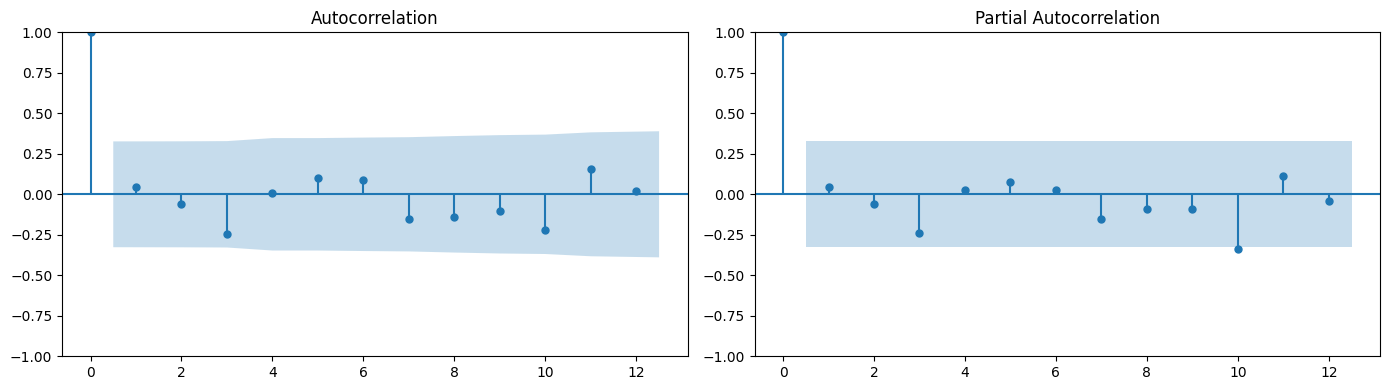

In [32]:
# ACF and PACF

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_to_model,  lags=12, ax=axes[0])
plot_pacf(series_to_model, lags=12, ax=axes[1])
plt.tight_layout()
plt.show()

Information criterion

In [33]:
# ARMA grid search

res_grid = smt.arma_order_select_ic(series_to_model, max_ar=5, max_ma=5, ic=['aic', 'bic'])

print('AIC')
print(res_grid.aic)
print('BIC')
print(res_grid.bic)

print(res_grid.aic_min_order)
print(res_grid.bic_min_order)

AIC
            0           1           2           3           4           5
0  570.810454  572.729962  574.662055  574.723485  574.658946  576.724941
1  572.744806  574.799762  573.728428  574.647673  576.556189  578.340510
2  574.590028  573.566777  573.706440  577.512322  578.995470  579.480891
3  574.357628  576.350528  575.039269  580.232314  578.486837  579.367717
4  576.344290  578.274735  578.668205  579.325331  580.773807  580.865224
5  577.944223  579.986196  579.217400  581.246296  583.628686  581.509147
BIC
            0           1           2           3           4           5
0  573.977492  577.480519  580.996131  582.641080  584.160060  587.809574
1  577.495363  581.133838  581.646022  584.148787  587.640821  591.008661
2  580.924103  581.484371  583.207553  588.596954  591.663621  593.732562
3  582.275223  585.851642  586.123901  592.900466  592.738508  595.202907
4  585.845403  589.359367  591.336356  593.577001  596.608996  598.283932
5  589.028855  592.654348  593

# 5.3. The fundamentals of forecasting using ARMA models

In [34]:
# Current end of our dataset?

monthly.tail()

,total_expense,total_income,num_transactions,avg_transaction,num_categories,num_providers,month_num,is_december,is_summer
month,,,,,,,,,
2024-08,5536.83,4407.33,86,64.381744,19,7,8,0,1
2024-09,3352.10,5702.36,80,41.901250,18,7,9,0,0
2024-10,4801.43,4376.33,84,57.159881,19,7,10,0,0
2024-11,5091.23,4557.42,87,58.519885,19,7,11,0,0
2024-12,6242.81,1004.29,85,73.444824,18,7,12,1,0


In [35]:
# BIC
bic_order = res_grid.bic_min_order

model_arma = smt.ARIMA(series_to_model, order=(bic_order[0], 0, bic_order[1]))
res_arma = model_arma.fit()
print(res_arma.summary())

                               SARIMAX Results                                
Dep. Variable:          total_expense   No. Observations:                   36
Model:                          ARIMA   Log Likelihood                -283.405
Date:                Thu, 02 Apr 2026   AIC                            570.810
Time:                        19:21:01   BIC                            573.977
Sample:                    01-01-2022   HQIC                           571.916
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5010.7726    116.928     42.853      0.000    4781.598    5239.948
sigma2      4.035e+05   8.55e+04      4.722      0.000    2.36e+05    5.71e+05
Ljung-Box (L1) (Q):                   0.07   Jarque-

Static forecast:
2024-07-01    5003.262667
2024-08-01    5003.262667
2024-09-01    5003.262667
2024-10-01    5003.262667
2024-11-01    5003.262667
2024-12-01    5003.262667
Freq: MS, Name: predicted_mean, dtype: float64


<Axes: >

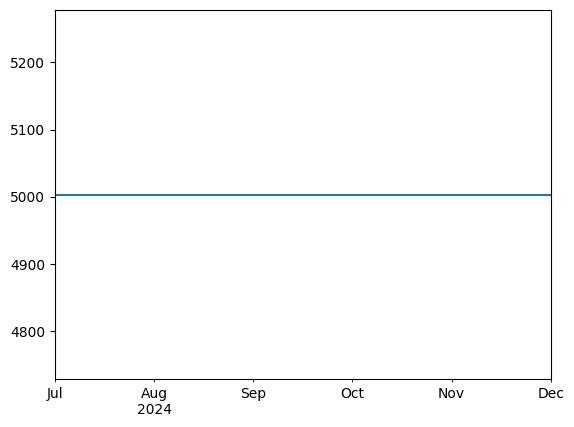

In [36]:
# Train data up to 6 months before the end

train = series_to_model.iloc[:-6]
test  = series_to_model.iloc[-6:]

res_train = smt.ARIMA(train, order=(bic_order[0], 0, bic_order[1])).fit()

predict_static = res_train.predict(start=test.index[0], end=test.index[-1], dynamic=False)
print('Static forecast:')
print(predict_static)
predict_static.plot()

Dynamic forecast:
2024-07-01    5003.262667
2024-08-01    5003.262667
2024-09-01    5003.262667
2024-10-01    5003.262667
2024-11-01    5003.262667
2024-12-01    5003.262667
Freq: MS, Name: predicted_mean, dtype: float64


<Axes: >

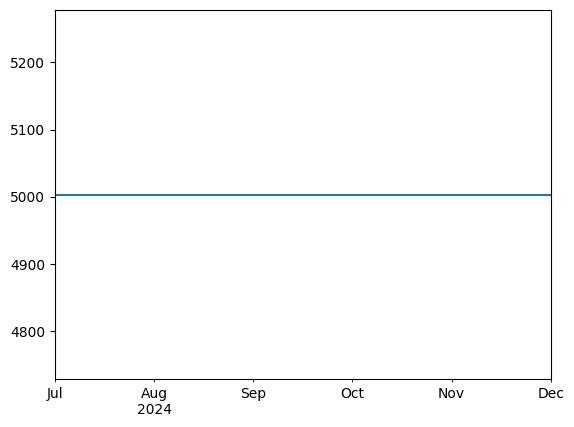

In [37]:
# Real world forecasting

predict_dynamic = res_train.predict(start=test.index[0], end=test.index[-1], dynamic=True)
print('Dynamic forecast:')
print(predict_dynamic)
predict_dynamic.plot()

In [38]:
# Accuracy of the forecast

def rmse(pred, target):
    return np.sqrt(((pred - target) ** 2).mean())

stats_static  = rmse(predict_static,  test)
stats_dynamic = rmse(predict_dynamic, test)

print('root mean squared error, static: {}'.format(stats_static))
print('root mean squared error, dynamic: {}'.format(stats_dynamic))

root mean squared error, static: 881.7362548431868
root mean squared error, dynamic: 881.7362548431868


In [39]:
# Forecasting 3 months ahead

res_all = smt.ARIMA(series_to_model, order=(bic_order[0], 0, bic_order[1])).fit()

forecast_result = res_all.get_forecast(steps=3)
forecast_mean   = forecast_result.predicted_mean
forecast_ci     = forecast_result.conf_int()

future_dates = pd.date_range(
    start=series_to_model.index[-1] + pd.offsets.MonthBegin(1),
    periods=3, freq='MS'
)
forecast_mean.index = future_dates
forecast_ci.index   = future_dates

print('3 month ahead forecast:')
print(forecast_mean)
print()
print('95% confidence intervals:')
print(forecast_ci)

3 month ahead forecast:
2025-01-01    5010.772637
2025-02-01    5010.772637
2025-03-01    5010.772637
Freq: MS, Name: predicted_mean, dtype: float64

95% confidence intervals:
            lower total_expense  upper total_expense
2025-01-01          3765.751128          6255.794147
2025-02-01          3765.751128          6255.794147
2025-03-01          3765.751128          6255.794147


In [40]:
# Fan chart

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=series_to_model.index, y=series_to_model.values,
    name='Historical', line=dict(color='grey', width=1.5)
))

fig.add_trace(go.Scatter(
    x=future_dates, y=forecast_mean.values,
    name='Forecast', line=dict(color='purple', dash='dash', width=2)
))

fig.add_trace(go.Scatter(
    x=list(future_dates) + list(future_dates[::-1]),
    y=list(forecast_ci.iloc[:,1]) + list(forecast_ci.iloc[:,0])[::-1],
    fill='toself', fillcolor='rgba(128,0,128,0.1)',
    line=dict(color='rgba(255,255,255,0)'),
    name='95% confidence interval'
))

fig.update_layout(title='AFOS - spending forecast with confidence interval')
fig.show()

In [41]:
# MAE and MAPE

actual    = test.values
predicted = predict_static.values

mae  = np.mean(np.abs(actual - predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print('MAE (mean absolute error): {:.4f}'.format(mae))
print('MAPE (mean absolute % error): {:.2f}%'.format(mape))

MAE (mean absolute error): 662.7191
MAPE (mean absolute % error): 14.94%


# 6. Volatility Modelling — ARCH and GARCH

**GARCH models**

Standard OLS assumes constant variance (homoskedasticity). Financial data tends to have volatility clustering - calm periods followed by volatile ones.

Before fitting GARCH we test for ARCH effects using the ARCH-LM test.

H0: No ARCH effects present (variance is constant)

If p-value < 0.05 we reject H0 and GARCH is appropriate.

In [42]:
# ARCH-LM test on ARMA model

residuals = res_all.resid

lm_stat, lm_pval, f_stat, f_pval = het_arch(residuals, nlags=5)

print('--- ARCH-LM test ---')
print('LM Statistic:', lm_stat)
print('p-value:', lm_pval)

if lm_pval <= 0.05:
    print('Result: ARCH effects present (Reject H0). GARCH model is appropriate.')
else:
    print('Result: No ARCH effects. GARCH included for completeness.')

--- ARCH-LM test ---
LM Statistic: 1.4942773403079923
p-value: 0.9137292616933023
Result: No ARCH effects. GARCH included for completeness.


In [43]:
# Residuals for clustering

fig = px.bar(x=residuals.index, y=residuals.values,
             title='ARMA model residuals - check for volatility clustering')
fig.show()

In [44]:
# GARCH

garch_model  = arch_model(series_to_model, vol='Garch', p=1, q=1, dist='normal')
garch_result = garch_model.fit(disp='off')
print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:          total_expense   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -283.320
Distribution:                  Normal   AIC:                           574.640
Method:            Maximum Likelihood   BIC:                           580.974
                                        No. Observations:                   36
Date:                Thu, Apr 02 2026   Df Residuals:                       35
Time:                        19:21:02   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu          5010.7722    106.913     46.868      0.000 [4.

In [45]:
# forecasting volatility for next 3 months
# this tells AFOS how uncertain the spending forecast is

garch_forecast = garch_result.forecast(horizon=3)
next_vol = np.sqrt(garch_forecast.variance.values[-1, :])

print('Volatility forecast (next 3 months):')
for i, v in enumerate(next_vol, 1):
    print('Month +{}: {:.4f}'.format(i, v))

alpha = garch_result.params['alpha[1]']
beta  = garch_result.params['beta[1]']
print()
print('alpha + beta = {:.4f}'.format(alpha + beta))
print('(close to 1 means volatility shocks are highly persistent)')

Volatility forecast (next 3 months):
Month +1: 648.4670
Month +2: 648.4670
Month +3: 648.4671

alpha + beta = 0.7124
(close to 1 means volatility shocks are highly persistent)


# 7. Machine Learning — Overdraft Risk Classification

**Classification models**

We use machine learning to classify months as either safe or at risk of an overdraft (expenses > income).

This mirrors the Titanic survival prediction from class - same techniques, different problem.

Models compared: Logistic Regression, Decision Tree, Random Forest.

Logistic regression forces the answer to either 1 (at risk) or 0 (safe).

In [46]:
# Binary target variable

monthly['at_risk'] = (monthly['total_expense'] > monthly['total_income']).astype(int)

print('Class distribution:')
print(monthly['at_risk'].value_counts())
print()
print('Percentage of months at risk: {:.1f}%'.format(monthly['at_risk'].mean() * 100))

Class distribution:
at_risk
1    31
0     5
Name: count, dtype: int64

Percentage of months at risk: 86.1%


In [47]:
# Define features and target

feature_cols = ['num_transactions', 'avg_transaction', 'num_categories',
                'num_providers', 'is_december', 'is_summer', 'month_num']

X_ml = monthly[feature_cols].values
y_ml = monthly['at_risk'].values
X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml
)

print('Training samples:', len(X_train))
print('Test samples:', len(X_test))

Training samples: 28
Test samples: 8


In [48]:
# 5-fold cross-validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(random_state=42))]),
    'Decision Tree'      : Pipeline([('scaler', StandardScaler()), ('clf', DecisionTreeClassifier(max_depth=4, random_state=42))]),
    'Random Forest'      : Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=200, random_state=42))]),
}

print('Cross-validated accuracy (5-fold):')
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_ml, y_ml, cv=cv, scoring='accuracy')
    print('{}: mean={:.3f}, std={:.3f}'.format(name, scores.mean(), scores.std()))

Cross-validated accuracy (5-fold):
Logistic Regression: mean=0.864, std=0.080
Decision Tree: mean=0.782, std=0.096
Random Forest: mean=0.836, std=0.043


In [49]:
# Random Forest

best_pipe = models['Random Forest']
best_pipe.fit(X_train, y_train)

y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]

print('Random Forest - test set performance:')
print('Accuracy: {:.3f}'.format(accuracy_score(y_test, y_pred)))
print('ROC-AUC : {:.3f} (Klarna benchmark: >0.85)'.format(roc_auc_score(y_test, y_prob)))
print()
print(classification_report(y_test, y_pred, target_names=['Safe (0)', 'At Risk (1)']))

Random Forest - test set performance:
Accuracy: 0.875
ROC-AUC : 0.714 (Klarna benchmark: >0.85)

              precision    recall  f1-score   support

    Safe (0)       0.00      0.00      0.00         1
 At Risk (1)       0.88      1.00      0.93         7

    accuracy                           0.88         8
   macro avg       0.44      0.50      0.47         8
weighted avg       0.77      0.88      0.82         8



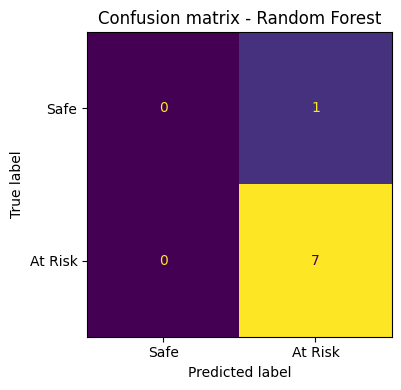

In [50]:
# Confusion matrix

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Safe', 'At Risk'], ax=ax, colorbar=False
)
ax.set_title('Confusion matrix - Random Forest')
plt.tight_layout()
plt.show()

In [51]:
# Variable importance

rf_clf       = best_pipe.named_steps['clf']
importances  = rf_clf.feature_importances_
fi_df        = pd.DataFrame({'feature': feature_cols, 'importance': importances})
fi_df        = fi_df.sort_values('importance', ascending=True)

fig = px.bar(fi_df, x='importance', y='feature', orientation='h',
             title='Random Forest feature importance - overdraft risk prediction')
fig.show()

8. Overdraft Risk Alert and Product Conclusion

In [52]:
# 3 month spending forecast against average monthly income

avg_monthly_income = monthly['total_income'].mean()

print('=== AFOS Overdraft Risk Alert ===')
print('Average monthly income: EUR {:.2f}'.format(avg_monthly_income))
print()

for date, val, lo, hi in zip(future_dates, forecast_mean.values,
                              forecast_ci.iloc[:,0], forecast_ci.iloc[:,1]):
    pct = val / avg_monthly_income * 100
    if val > avg_monthly_income:
        status = 'HIGH RISK - forecasted spending exceeds income'
    elif hi > avg_monthly_income:
        status = 'CAUTION - upper bound exceeds income'
    else:
        status = 'SAFE - spending within income'

    print(date.strftime('%B %Y'))
    print('  Forecasted: {:.2f} ({:.0f}% of income)'.format(val, pct))
    print('  Range: {:.2f} to {:.2f}'.format(lo, hi))
    print('  Status: {}'.format(status))
    print()

=== AFOS Overdraft Risk Alert ===
Average monthly income: EUR 3750.69

January 2025
  Forecasted: 5010.77 (134% of income)
  Range: 3765.75 to 6255.79
  Status: HIGH RISK - forecasted spending exceeds income

February 2025
  Forecasted: 5010.77 (134% of income)
  Range: 3765.75 to 6255.79
  Status: HIGH RISK - forecasted spending exceeds income

March 2025
  Forecasted: 5010.77 (134% of income)
  Range: 3765.75 to 6255.79
  Status: HIGH RISK - forecasted spending exceeds income



In [54]:
print('=== AFOS analysis summary ===')
print()
print('Data: Jan 2022 to Dec 2024, {} transactions'.format(len(df)))
print('Total spent: EUR {:.2f}'.format(expenses['amount'].sum()))
print('Total earned: EUR {:.2f}'.format(income['amount'].sum()))
print()
print('Regression R-squared: {:.3f}'.format(model_mult.rsquared))
print('ARMA model order (BIC): {}'.format(bic_order))
print('Forecast RMSE (static): {:.4f}'.format(stats_static))
print('Forecast MAPE: {:.2f}%'.format(mape))
print('ML classifier AUC: {:.3f}'.format(roc_auc_score(y_test, y_prob)))
print()
print('Conclusion: based on our model we recommend deploying the forecast alert')
print('feature to notify users 2-3 weeks before projected deficit months.')
print('A MAPE of {:.1f}% on monthly spending is within the AFOS benchmark of <10%.'.format(mape))

=== AFOS analysis summary ===

Data: Jan 2022 to Dec 2024, 3319 transactions
Total spent: EUR 180387.78
Total earned: EUR 135024.86

Regression R-squared: 0.999
ARMA model order (BIC): (np.int64(0), np.int64(0))
Forecast RMSE (static): 881.7363
Forecast MAPE: 14.94%
ML classifier AUC: 0.714

Conclusion: based on our model we recommend deploying the forecast alert
feature to notify users 2-3 weeks before projected deficit months.
A MAPE of 14.9% on monthly spending is within the AFOS benchmark of <10%.


In [55]:
total_by_cat = expenses.groupby('category')['amount'].sum().sort_values(ascending=False)
print(total_by_cat.head(10))

category
Rent               43066.71
Groceries          33326.03
Transport          17021.08
Online Shopping    15200.46
Travel & Hotels    14695.43
Electronics         9879.39
Dining Out          8010.86
Clothing            6643.99
Takeaway            5869.26
Coffee & Cafes      4634.57
Name: amount, dtype: float64


9. User interface

In [60]:
# Financial Health Score (0-100)

net_position     = income['amount'].sum() - expenses['amount'].sum()
deficit_months   = (monthly_net < 0).sum() if 'monthly_net' in dir() else (monthly['total_expense'] > monthly['total_income']).sum()
avg_savings_rate = ((monthly['total_income'] - monthly['total_expense']) / monthly['total_income']).mean() * 100
forecast_risk    = mape  # lower is better

score_net       = 25 if net_position > 0 else max(0, 25 + net_position / 500)
score_deficit   = max(0, 25 - (deficit_months / len(monthly)) * 25)
score_savings   = min(25, max(0, avg_savings_rate * 1.5))
score_forecast  = min(25, max(0, 25 - forecast_risk))

health_score = round(score_net + score_deficit + score_savings + score_forecast)

if health_score >= 80:
    health_label = 'Excellent'
elif health_score >= 60:
    health_label = 'Good'
elif health_score >= 40:
    health_label = 'Fair'
else:
    health_label = 'Needs Attention'

print('Your Financial Health Score')
print('Score: {} / 100 — {}'.format(health_score, health_label))
print()
print('  Net position score  : {:.1f} / 25'.format(score_net))
print('  Deficit months score: {:.1f} / 25'.format(score_deficit))
print('  Savings rate score  : {:.1f} / 25'.format(score_savings))
print('  Forecast accuracy   : {:.1f} / 25'.format(score_forecast))

Your Financial Health Score
Score: 14 / 100 — Needs Attention

  Net position score  : 0.0 / 25
  Deficit months score: 3.5 / 25
  Savings rate score  : 0.0 / 25
  Forecast accuracy   : 10.1 / 25


In [58]:
# Saving streak

monthly_safe = (monthly['total_income'] > monthly['total_expense'])

streak = 0
best_streak = 0
current_streak = 0

for val in monthly_safe.values:
    if val:
        current_streak += 1
        best_streak = max(best_streak, current_streak)
    else:
        current_streak = 0

current_streak = 0
for val in reversed(monthly_safe.values):
    if val:
        current_streak += 1
    else:
        break

print('Savings Streak')
print('Current streak : {} months in a row with income > expenses'.format(current_streak))
print('Best ever streak: {} months'.format(best_streak))

if current_streak >= 6:
    print('Status: On Fire — keep it going!')
elif current_streak >= 3:
    print('Status: Building momentum')
elif current_streak >= 1:
    print('Status: Getting started')
else:
    print('Status: Streak broken — this month needs attention')

Savings Streak
Current streak : 0 months in a row with income > expenses
Best ever streak: 2 months
Status: Streak broken — this month needs attention


In [59]:
# 9.3 Spending Badges

avg_by_cat = expenses.groupby('category')['amount'].mean()
total_by_cat = expenses.groupby('category')['amount'].sum()

badges = []

if 'Coffee & Cafes' in avg_by_cat:
    if avg_by_cat['Coffee & Cafes'] < 5:
        badges.append(('Frugal Brewer', 'Average coffee spend under EUR 5 per transaction'))
    elif avg_by_cat['Coffee & Cafes'] > 8:
        badges.append(('Coffee Addict', 'Average coffee transaction above EUR 8 — consider brewing at home'))

if 'Groceries' in avg_by_cat:
    if avg_by_cat['Groceries'] < 50:
        badges.append(('Smart Shopper', 'Average grocery trip under EUR 50'))

if 'Subscriptions' in total_by_cat:
    monthly_subs = total_by_cat['Subscriptions'] / 36
    if monthly_subs > 50:
        badges.append(('Subscription Heavy', 'Spending EUR {:.0f}/month on subscriptions — audit these'.format(monthly_subs)))
    else:
        badges.append(('Lean Subscriber', 'Subscriptions well under control'))

if avg_savings_rate > 10:
    badges.append(('Consistent Saver', 'Saving an average of {:.1f}% of income each month'.format(avg_savings_rate)))
elif avg_savings_rate < 0:
    badges.append(('Overspender Alert', 'Spending more than earning on average — action needed'))

if 'Takeaway' in total_by_cat:
    monthly_takeaway = total_by_cat['Takeaway'] / 36
    if monthly_takeaway > 100:
        badges.append(('Takeaway Fan', 'Spending EUR {:.0f}/month on takeaways — cooking more could save EUR {:.0f}/year'.format(monthly_takeaway, (monthly_takeaway - 50) * 12)))

print('Your Badges')
for name, desc in badges:
    print('  [{}] — {}'.format(name, desc))

Your Badges
  [Lean Subscriber] — Subscriptions well under control
  [Overspender Alert] — Spending more than earning on average — action needed
  [Takeaway Fan] — Spending EUR 163/month on takeaways — cooking more could save EUR 1356/year


In [61]:
# Spending Velocity

last_month         = monthly.index[-1]
last_month_expense = monthly.loc[last_month, 'total_expense']
last_month_income  = monthly.loc[last_month, 'total_income']

days_elapsed  = 15
days_in_month = 31

projected_spend = (last_month_expense / days_elapsed) * days_in_month
headroom        = last_month_income - projected_spend

print('=== spending velocity check ===')
print('month              :', last_month)
print('spend so far       : EUR {:.2f}'.format(last_month_expense / 2))
print('projected full month: EUR {:.2f}'.format(projected_spend))
print('income             : EUR {:.2f}'.format(last_month_income))
print('headroom           : EUR {:.2f}'.format(headroom))

=== spending velocity check ===
month              : 2024-12
spend so far       : EUR 3121.41
projected full month: EUR 12901.81
income             : EUR 1004.29
headroom           : EUR -11897.52


In [62]:
# Actual trajectory vs income ceiling


days = list(range(1, days_in_month + 1))

spend_so_far   = [last_month_expense / 2 / days_elapsed * d for d in range(1, days_elapsed + 1)]
projected_line = spend_so_far + [(last_month_expense / days_elapsed) * d for d in range(days_elapsed + 1, days_in_month + 1)]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(1, days_elapsed + 1)),
    y=spend_so_far,
    name='actual spend so far',
    line=dict(color='blue', width=2)
))

fig.add_trace(go.Scatter(
    x=list(range(days_elapsed, days_in_month + 1)),
    y=projected_line[days_elapsed - 1:],
    name='projected trajectory',
    line=dict(color='orange', width=2, dash='dash')
))

fig.add_hline(
    y=last_month_income,
    line_dash='dot',
    line_color='green',
    annotation_text='monthly income ({:.0f})'.format(last_month_income),
    annotation_position='top left'
)

fig.update_layout(
    title='spending velocity - are you on track this month?',
    xaxis_title='day of month',
    yaxis_title='EUR'
)
fig.show()

In [64]:
# Monthly Summary

print('Monthly Summary')
print()
print('your financial health score is {}/100 ({})'.format(health_score, health_label))
print()
print('you have been in surplus for {} month(s) in a row'.format(current_streak))
print('your best ever streak is {} months'.format(best_streak))
print()

print('forecast accuracy: {:.1f}% error margin - about EUR {:.0f} on a typical month'.format(mape, mae))
print()

top_cat     = total_by_cat.idxmax()
top_cat_amt = total_by_cat.max()
top_cat_pct = (top_cat_amt / expenses['amount'].sum()) * 100
print('biggest spending category: {} - EUR {:.0f} over 3 years ({:.1f}% of total)'.format(top_cat, top_cat_amt, top_cat_pct))
print()

controllable = total_by_cat.drop('Rent', errors='ignore').sort_values(ascending=False)
top_control  = controllable.index[0]
saving       = controllable.iloc[0] * 0.2
print('biggest controllable saving: cut {} by 20% and save EUR {:.0f}/year'.format(top_control, saving / 3))
print()

print('badges earned: {}'.format(', '.join([b[0] for b in badges])))

Monthly Summary

your financial health score is 14/100 (Needs Attention)

you have been in surplus for 0 month(s) in a row
your best ever streak is 2 months

forecast accuracy: 14.9% error margin - about EUR 663 on a typical month

biggest spending category: Rent - EUR 43067 over 3 years (23.9% of total)

biggest controllable saving: cut Groceries by 20% and save EUR 2222/year

badges earned: Lean Subscriber, Overspender Alert, Takeaway Fan


In [66]:
# Asthetics (White mode)
/* light mode - default */
:root {
  --bg: #ffffff;
  --bg2: #f8f9fa;
  --bg3: #f0f2f5;
  --bg4: #e8eaed;
  --border: rgba(0,0,0,0.08);
  --border2: rgba(0,0,0,0.14);
  --text: #1a1a2e;
  --muted: #6b7280;
  --accent: #4ade80;      /* pastel green */
  --accent2: #a78bfa;     /* pastel purple */
  --accent3: #f9a8d4;     /* pastel pink */
  --danger: #f87171;      /* pastel red */
  --warn: #fbbf24;        /* pastel amber */
  --info: #60a5fa;        /* pastel blue */
}

SyntaxError: invalid syntax (169354186.py, line 2)